# Exercice 6 - Prédiction du prix de smartphones

## Présentation du dataset

Le jeu de données utilisé est le "Smartphone Specifications & Pricing Dataset", disponible sur Kaggle à l'adresse suivante : https://www.kaggle.com/datasets/sharmajicoder/smartphones-specification-and-prices

Il s'agit d'un jeu de données **synthétique** de 1 000 000 de smartphones, générés pour reproduire des tendances réalistes du marché. Chaque ligne décrit un modèle par sa marque, son système d'exploitation, ses caractéristiques techniques (processeur, RAM, stockage, écran, batterie, appareils photo, connectivité, matériaux...) et son prix en roupies indiennes (Rs).

## Objectif

On cherche à prédire le prix d'un smartphone (`price_inr`, en Rs) à partir de ses caractéristiques techniques (processeur, mémoire, écran, batterie, appareils photo, connectivité, matériaux, etc.) : c'est un problème de **régression**.

Pour un fabricant, ce type de modèle peut aider à positionner le prix d'un nouveau modèle avant son lancement, en le comparant à des modèles existants ayant des caractéristiques proches. Pour une marketplace ou un comparateur de prix, il peut aussi servir à repérer des annonces dont le prix affiché est anormalement élevé ou faible par rapport aux spécifications du téléphone.

In [1]:
import time

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error

RANDOM_STATE = 0

In [2]:
df = pd.read_csv("dataset smartphones/smartphone_dataset_1M.csv")
df.shape

(1000000, 33)

Le dataset contient 1 000 000 lignes et 33 colonnes, sans valeur manquante.

In [3]:
df.head()

,brand,model_name,os,price_inr,launch_year,5g_support,dual_sim,expandable_storage,water_resistance,wireless_charging,...,display_size_inch,display_type,refresh_rate_hz,battery_mah,fast_charging_w,rear_camera_mp,front_camera_mp,camera_setup,weight_g,thickness_mm
0,Google,Google_2528,Android,71511,2020,1,1,0,0,1,...,6.10,AMOLED,120,4657,25,200,16,Wide,175.2,8.29
1,Samsung,Samsung_9006,Android,57511,2018,1,0,1,0,0,...,5.77,LCD,120,3817,65,50,8,"Telephoto, Wide",175.6,7.41
2,Google,Google_2059,Android,76042,2022,0,1,1,1,0,...,6.10,LCD,90,5069,25,200,32,"Wide, Ultra-Wide",184.0,8.89
3,Realme,Realme_5737,Android,26916,2021,0,1,0,1,0,...,6.28,AMOLED,60,4323,45,50,8,"Macro, Wide, Telephoto, Depth",173.6,7.67
4,OnePlus,OnePlus_5548,Android,31505,2022,1,0,0,0,1,...,6.45,AMOLED,60,6497,25,50,16,"Depth, Macro, Telephoto, Wide",197.9,9.41


In [4]:
df.isna().sum().sum()

np.int64(0)

## Description des variables moins évidentes

La plupart des colonnes sont auto-explicatives (prix, année de sortie, poids...), mais certaines méritent une explication avant de les utiliser :

- `cpu_score` / `gpu_score` : scores de performance synthétiques attribués par les auteurs du dataset, sans échelle ou benchmark réel connu (ce ne sont pas des scores AnTuTu ou Geekbench). On observe même des valeurs négatives, ce qui est probablement un artefact de la génération synthétique des données ; on les conserve telles quelles car elles restent très informatives pour le prix (voir analyse de corrélation plus bas).
- `chipset` : nom du processeur (8 modèles présents, par ex. Snapdragon 8 Gen 2, A17 Bionic, Helio G85), traité comme variable catégorielle.
- `build_material` : matériau du châssis (Metal / Glass / Plastic).
- `wifi_version` / `bluetooth_version` : norme WiFi (5 / 6 / 6E) et version Bluetooth (de 4.2 à 5.3).
- `screen_to_body_ratio` : proportion de la face avant occupée par l'écran, en %.
- `colors_available` : nombre de coloris proposés pour le modèle.
- `warranty_years` : durée de garantie constructeur, en années.
- `camera_setup` : liste textuelle des types de capteurs photo arrière (par ex. "Wide, Ultra-Wide, Macro"), qu'on transforme en variables exploitables lors du preprocessing.

## Analyse exploratoire

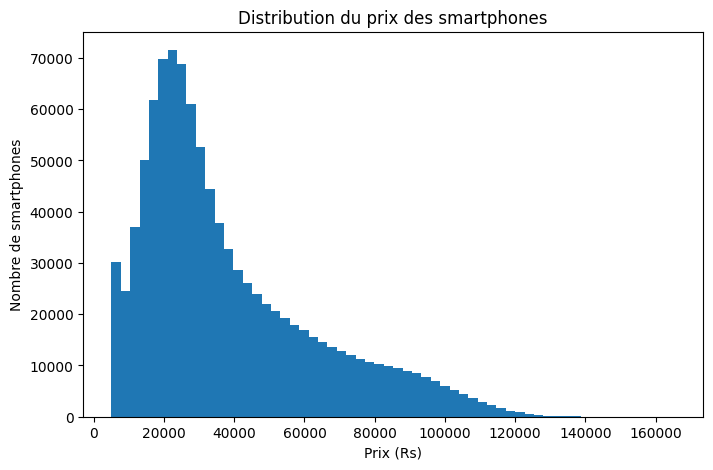

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df["price_inr"], bins=60)
ax.set_xlabel("Prix (Rs)")
ax.set_ylabel("Nombre de smartphones")
ax.set_title("Distribution du prix des smartphones")
plt.show()

La distribution du prix est étalée vers la droite : la majorité des smartphones se situent entre 15 000 Rs et 30 000 Rs, et une minorité de modèles haut de gamme dépassent 100 000 Rs.

In [6]:
q1, q3 = df["price_inr"].quantile([0.25, 0.75])
iqr = q3 - q1
low_bound, high_bound = q1 - 1.5 * iqr, q3 + 1.5 * iqr
n_price_outliers = ((df["price_inr"] < low_bound) | (df["price_inr"] > high_bound)).sum()
print(f"bornes IQR pour price_inr : [{low_bound:.0f}, {high_bound:.0f}] Rs")
print(f"smartphones hors bornes : {n_price_outliers} ({n_price_outliers / len(df):.2%})")

n_neg_scores = ((df["cpu_score"] < 0) | (df["gpu_score"] < 0)).sum()
print(f"lignes avec cpu_score ou gpu_score negatif : {n_neg_scores} ({n_neg_scores / len(df):.2%})")

bornes IQR pour price_inr : [-26604, 98132] Rs
smartphones hors bornes : 30775 (3.08%)
lignes avec cpu_score ou gpu_score negatif : 7773 (0.78%)


Avec la règle des 1.5 IQR, les bornes obtenues pour `price_inr` sont [-26604, 98132] Rs : la borne basse n'a pas de sens (le prix est positif), ce qui montre simplement que la distribution est étalée vers la droite, comme observé sur l'histogramme. 30 775 smartphones (3.08%) ont un prix supérieur à la borne haute : il s'agit des modèles haut de gamme (notamment Apple), pas d'erreurs de saisie, donc on les garde dans le dataset.

On note aussi que 0.78% des lignes ont un `cpu_score` ou un `gpu_score` négatif. Cette proportion est faible, donc on conserve ces lignes telles quelles plutôt que de les retirer, d'autant que rien n'indique qu'il s'agisse d'erreurs plutôt que d'un artefact voulu de la génération synthétique.

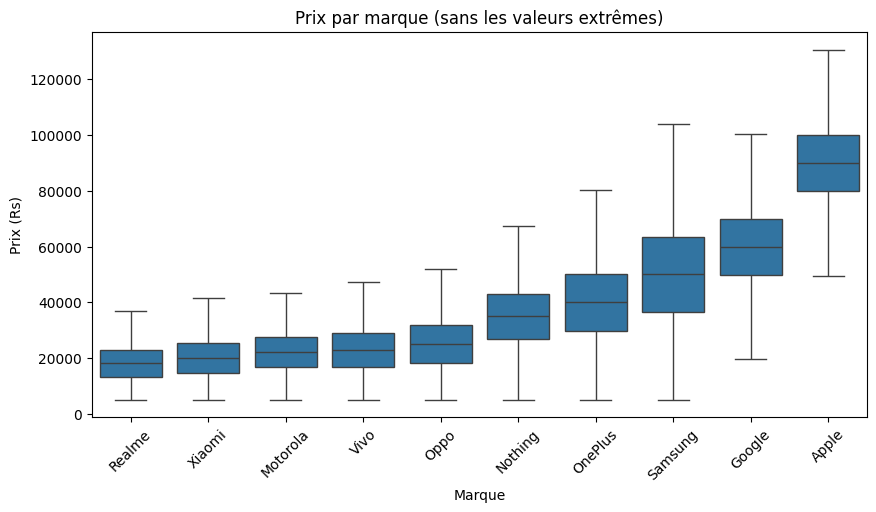

In [7]:
order = df.groupby("brand")["price_inr"].median().sort_values().index

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x="brand", y="price_inr", order=order, ax=ax, showfliers=False)
ax.set_xlabel("Marque")
ax.set_ylabel("Prix (Rs)")
ax.set_title("Prix par marque (sans les valeurs extrêmes)")
plt.xticks(rotation=45)
plt.show()

On observe des écarts de prix nets entre marques. Apple (iOS) se situe nettement au-dessus des autres marques, qui sont toutes sous Android. Les valeurs extrêmes sont masquées pour rendre le graphique lisible.

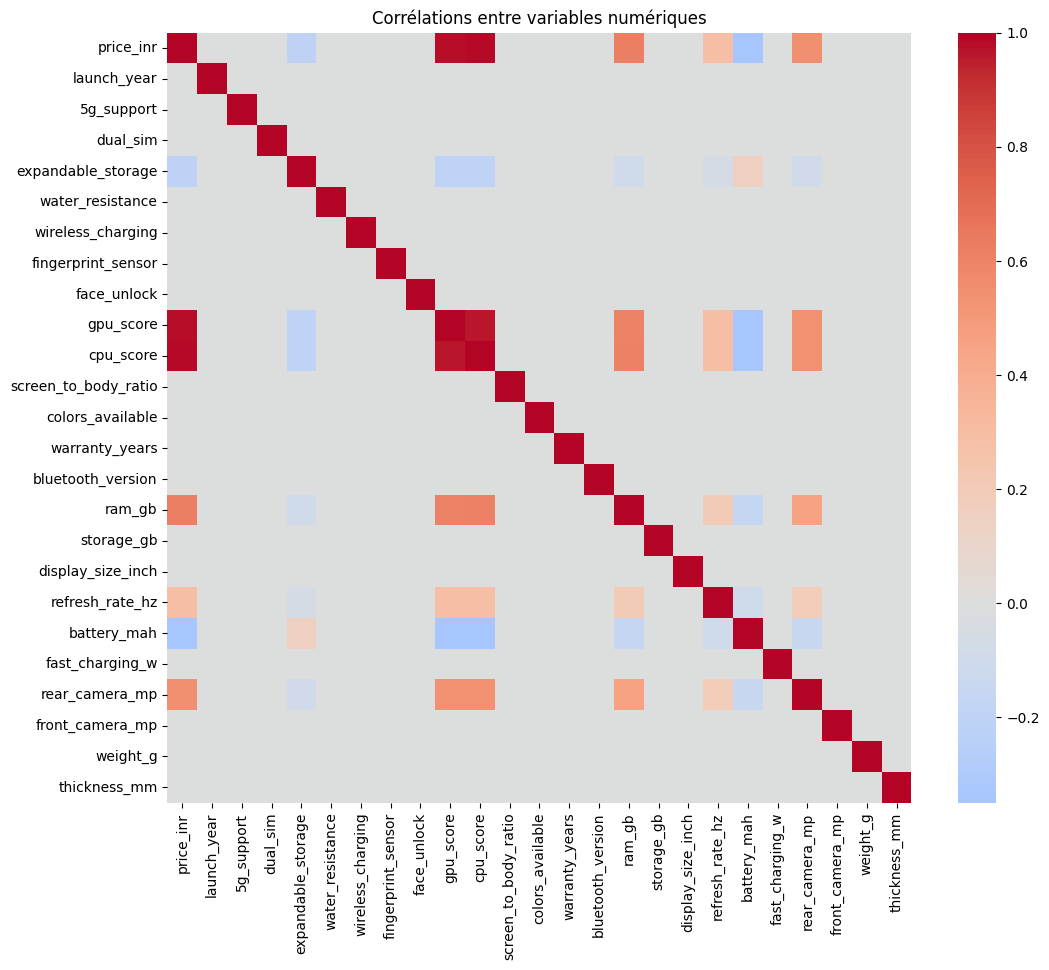

In [8]:
num_cols_corr = df.select_dtypes(include="number").columns
corr = df[num_cols_corr].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, ax=ax)
ax.set_title("Corrélations entre variables numériques")
plt.show()

Deux variables se distinguent très nettement : `cpu_score` (corrélation environ 0.99) et `gpu_score` (corrélation environ 0.98). Viennent ensuite `ram_gb` (environ 0.62), `rear_camera_mp` (environ 0.55) et `refresh_rate_hz` (environ 0.30), toutes corrélées positivement au prix. À l'inverse, `battery_mah` est corrélée négativement (environ -0.35), de même que `expandable_storage` (environ -0.21). La plupart des autres variables numériques (binaires de connectivité, `screen_to_body_ratio`, `colors_available`, etc.) ont une corrélation linéaire quasi nulle avec le prix.

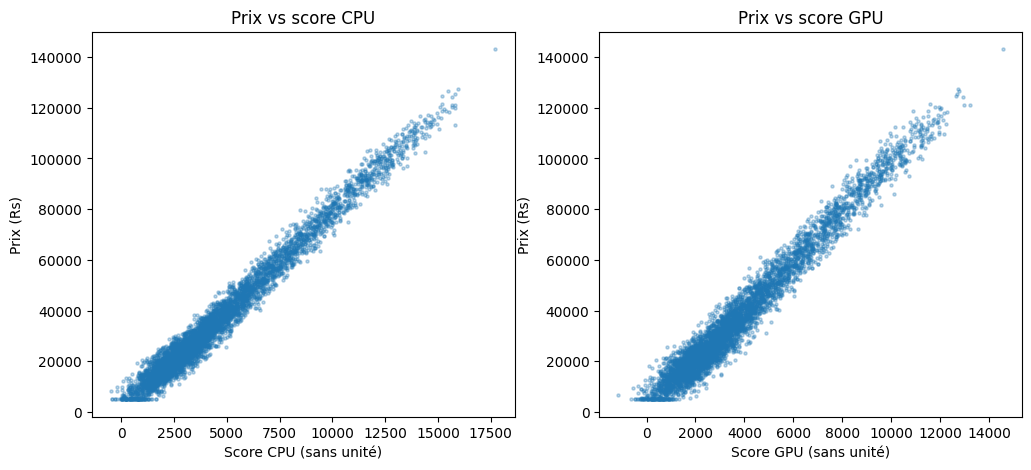

In [9]:
sample = df.sample(5000, random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(sample["cpu_score"], sample["price_inr"], s=5, alpha=0.3)
axes[0].set_xlabel("Score CPU (sans unité)")
axes[0].set_ylabel("Prix (Rs)")
axes[0].set_title("Prix vs score CPU")

axes[1].scatter(sample["gpu_score"], sample["price_inr"], s=5, alpha=0.3)
axes[1].set_xlabel("Score GPU (sans unité)")
axes[1].set_ylabel("Prix (Rs)")
axes[1].set_title("Prix vs score GPU")
plt.show()

Le prix suit une relation quasiment linéaire avec les scores CPU et GPU, ce qui explique les très fortes corrélations observées.

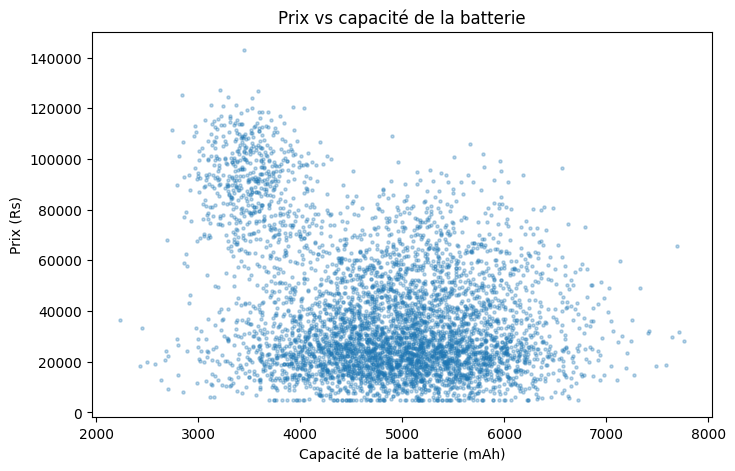

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(sample["battery_mah"], sample["price_inr"], s=5, alpha=0.3)
ax.set_xlabel("Capacité de la batterie (mAh)")
ax.set_ylabel("Prix (Rs)")
ax.set_title("Prix vs capacité de la batterie")
plt.show()

La relation est négative : dans ce dataset, les smartphones les plus chers ont tendance à avoir une batterie moins capacitive. C'est contre-intuitif par rapport au marché réel, mais on garde le dataset tel quel puisqu'il est synthétique et que l'objectif est de modéliser la relation telle qu'elle existe dans les données.

## Préparation des données

- `model_name` est juste la concaténation de la marque et d'un identifiant aléatoire (vérifié sur l'ensemble du dataset), on la supprime.
- `camera_setup` liste les types de capteurs photo (par exemple "Wide, Ultra-Wide, Macro"). On en extrait le nombre de capteurs (`num_cameras`) et un indicateur binaire par type de capteur, puis on supprime la colonne d'origine.
- Les variables catégorielles restantes (`brand`, `os`, `build_material`, `wifi_version`, `chipset`, `display_type`) sont encodées en one-hot.
- Les variables numériques sont standardisées pour le modèle linéaire.
- Séparation train / test : 80% / 20%.

In [11]:
camera_lists = df["camera_setup"].str.split(",").apply(lambda lst: [c.strip() for c in lst])

camera_types = ["Wide", "Ultra-Wide", "Telephoto", "Macro", "Depth"]
for cam in camera_types:
    col_name = "cam_" + cam.lower().replace("-", "")
    df[col_name] = camera_lists.apply(lambda lst: int(cam in lst))

df["num_cameras"] = camera_lists.apply(len)

df = df.drop(columns=["model_name", "camera_setup"])

In [12]:
y = df["price_inr"]
X = df.drop(columns=["price_inr"])

cat_cols = ["brand", "os", "build_material", "wifi_version", "chipset", "display_type"]
num_cols = [c for c in X.columns if c not in cat_cols]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", StandardScaler(), num_cols),
])

## Modèle 1 : régression Ridge

Vu la relation quasi linéaire observée entre le prix et certaines variables (CPU, GPU), une régression linéaire régularisée est un point de départ naturel. `RidgeCV` choisit automatiquement la valeur de l'hyperparamètre de régularisation par validation croisée sur le train set.

In [13]:
ridge = Pipeline([
    ("prep", preprocessor),
    ("model", RidgeCV(alphas=np.logspace(-2, 3, 12))),
])
t0 = time.time()
ridge.fit(X_train, y_train)
ridge_fit_time = time.time() - t0
ridge.named_steps["model"].alpha_

1.873817422860383

In [14]:
def get_scores(model):
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)
    return {
        "R2_train": r2_score(y_train, pred_train),
        "R2_test": r2_score(y_test, pred_test),
        "MAE_train": mean_absolute_error(y_train, pred_train),
        "MAE_test": mean_absolute_error(y_test, pred_test),
    }


ridge_scores = get_scores(ridge)
ridge_scores

{'R2_train': 0.9863383201584126,
 'R2_test': 0.9864534908327698,
 'MAE_train': 2327.9112257123043,
 'MAE_test': 2326.292500363606}

### Effet de la standardisation

On vérifie l'intérêt de la standardisation des variables numériques pour Ridge, en comparant avec un Ridge entraîné sur les mêmes variables non standardisées (l'encodage one-hot des variables catégorielles reste identique).

In [15]:
preprocessor_no_scaling = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", "passthrough", num_cols),
])

ridge_no_scaling = Pipeline([
    ("prep", preprocessor_no_scaling),
    ("model", RidgeCV(alphas=np.logspace(-2, 3, 12))),
])
ridge_no_scaling.fit(X_train, y_train)

ridge_no_scaling_scores = get_scores(ridge_no_scaling)
ridge_no_scaling_scores

{'R2_train': 0.9863383201730608,
 'R2_test': 0.9864534886869519,
 'MAE_train': 2327.911547403008,
 'MAE_test': 2326.2928477816904}

Sans standardisation, le Ridge obtient un R2 test d'environ 0.9865 et une MAE test d'environ 2326 Rs, c'est-à-dire des résultats quasiment identiques à la version standardisée (R2 test environ 0.9865, MAE test environ 2326 Rs). La standardisation ne change donc pas les performances ici, car `RidgeCV` recalibre simplement son hyperparamètre de régularisation `alpha` pour compenser l'échelle des variables. La standardisation reste toutefois une bonne pratique : elle rend l'hyperparamètre `alpha` interprétable de façon comparable entre variables et évite qu'une variable à grande échelle (par exemple `cpu_score`) ne soit artificiellement moins pénalisée qu'une variable à petite échelle.

## Modèle 2 : Histogram Gradient Boosting

`HistGradientBoostingRegressor` est un modèle d'arbres en gradient boosting, basé sur un histogramme des features, ce qui le rend efficace sur un dataset d'1 million de lignes. Il peut capturer des relations non linéaires et des interactions entre variables que le modèle linéaire ne peut pas représenter.

Pour choisir le `learning_rate`, on compare 3 valeurs par validation croisée (3 folds) sur un sous-échantillon de 100 000 lignes du train set, afin de garder un temps de calcul raisonnable.

In [16]:
sample_idx = X_train.sample(100_000, random_state=RANDOM_STATE).index
X_sample = X_train.loc[sample_idx]
y_sample = y_train.loc[sample_idx]

for lr in [0.05, 0.1, 0.2]:
    model = Pipeline([
        ("prep", preprocessor),
        ("model", HistGradientBoostingRegressor(learning_rate=lr, random_state=RANDOM_STATE)),
    ])
    cv_scores = cross_val_score(model, X_sample, y_sample, cv=3, scoring="r2")
    print(f"learning_rate={lr} -> R2 cv = {cv_scores.mean():.4f}")

learning_rate=0.05 -> R2 cv = 0.9877


learning_rate=0.1 -> R2 cv = 0.9877


learning_rate=0.2 -> R2 cv = 0.9876


Les trois valeurs de `learning_rate` donnent des résultats quasiment identiques (R2 de validation croisée environ 0.988). On garde donc la valeur par défaut (0.1).

In [17]:
hgb = Pipeline([
    ("prep", preprocessor),
    ("model", HistGradientBoostingRegressor(learning_rate=0.1, random_state=RANDOM_STATE)),
])
t0 = time.time()
hgb.fit(X_train, y_train)
hgb_fit_time = time.time() - t0

hgb_scores = get_scores(hgb)
hgb_scores

{'R2_train': 0.9880895911250271,
 'R2_test': 0.9881488853254728,
 'MAE_train': 2152.4025743432408,
 'MAE_test': 2154.7769485568124}

## Comparaison visuelle des modèles

On compare les prédictions des deux modèles sur un échantillon du test set (5000 points, pour la lisibilité des graphiques). La diagonale rouge représente une prédiction parfaite.

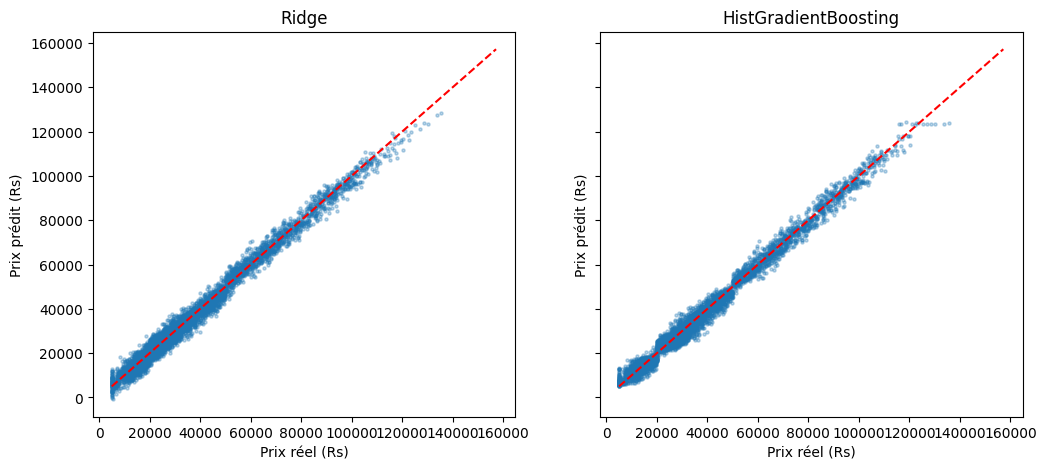

In [18]:
test_sample_idx = X_test.sample(5000, random_state=RANDOM_STATE).index
X_test_sample = X_test.loc[test_sample_idx]
y_test_sample = y_test.loc[test_sample_idx]

pred_ridge = ridge.predict(X_test_sample)
pred_hgb = hgb.predict(X_test_sample)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
lims = [y_test.min(), y_test.max()]

axes[0].scatter(y_test_sample, pred_ridge, s=5, alpha=0.3)
axes[0].plot(lims, lims, "r--")
axes[0].set_xlabel("Prix réel (Rs)")
axes[0].set_ylabel("Prix prédit (Rs)")
axes[0].set_title("Ridge")

axes[1].scatter(y_test_sample, pred_hgb, s=5, alpha=0.3)
axes[1].plot(lims, lims, "r--")
axes[1].set_xlabel("Prix réel (Rs)")
axes[1].set_ylabel("Prix prédit (Rs)")
axes[1].set_title("HistGradientBoosting")
plt.show()

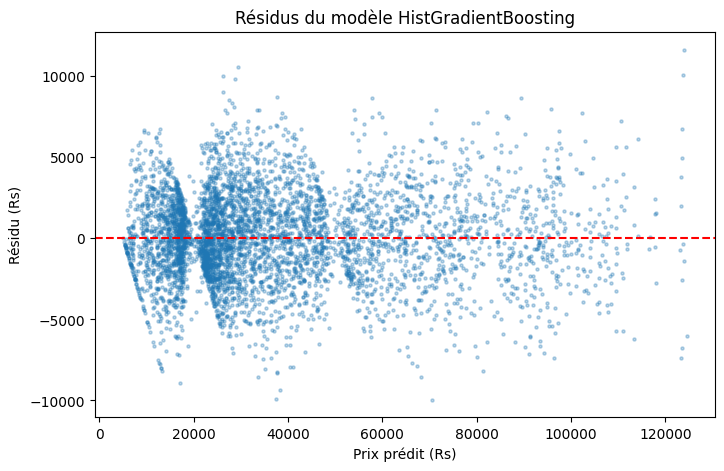

In [19]:
residuals = y_test_sample - pred_hgb

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(pred_hgb, residuals, s=5, alpha=0.3)
ax.axhline(0, color="r", linestyle="--")
ax.set_xlabel("Prix prédit (Rs)")
ax.set_ylabel("Résidu (Rs)")
ax.set_title("Résidus du modèle HistGradientBoosting")
plt.show()

In [20]:
residuals_full = y_test - hgb.predict(X_test)

for low, high in [(0, 30000), (30000, 60000), (60000, 100000), (100000, 200000)]:
    mask = (y_test >= low) & (y_test < high)
    print(f"prix in [{low}, {high}) -> ecart-type des residus = {residuals_full[mask].std():.0f} Rs (n={mask.sum()})")

prix in [0, 30000) -> ecart-type des residus = 2432 Rs (n=98528)
prix in [30000, 60000) -> ecart-type des residus = 2837 Rs (n=63434)
prix in [60000, 100000) -> ecart-type des residus = 3059 Rs (n=32715)
prix in [100000, 200000) -> ecart-type des residus = 3498 Rs (n=5323)


L'écart-type des résidus augmente avec le prix : l'erreur absolue du modèle est plus importante pour les smartphones haut de gamme. C'est cohérent avec le graphique de résidus ci-dessus, et assez naturel car l'échelle de prix est plus grande pour ces modèles.

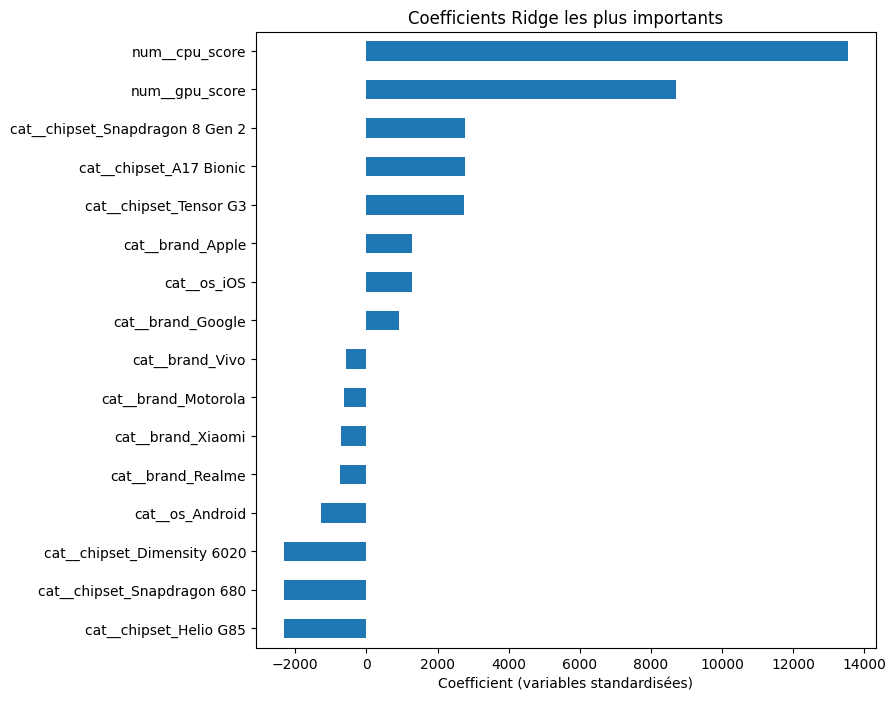

In [21]:
feature_names = ridge.named_steps["prep"].get_feature_names_out()
coefs = ridge.named_steps["model"].coef_

coef_series = pd.Series(coefs, index=feature_names).sort_values()
top_coefs = pd.concat([coef_series.head(8), coef_series.tail(8)])

fig, ax = plt.subplots(figsize=(8, 8))
top_coefs.plot(kind="barh", ax=ax)
ax.set_xlabel("Coefficient (variables standardisées)")
ax.set_title("Coefficients Ridge les plus importants")
plt.show()

Les coefficients confirment l'analyse de corrélation : `cpu_score` et `gpu_score` ont de très loin les coefficients les plus élevés. On retrouve ensuite les chipsets haut de gamme (Snapdragon 8 Gen 2, A17 Bionic, Tensor G3) et la marque Apple / iOS du côté positif, et les chipsets d'entrée de gamme (Helio G85, Snapdragon 680, Dimensity 6020) du côté négatif.

In [22]:
results = pd.DataFrame([ridge_scores, hgb_scores], index=["Ridge", "HistGradientBoosting"])
results["fit_time_s"] = [ridge_fit_time, hgb_fit_time]
results

,R2_train,R2_test,MAE_train,MAE_test,fit_time_s
Ridge,0.986338,0.986453,2327.911226,2326.292500,7.073380
HistGradientBoosting,0.988090,0.988149,2152.402574,2154.776949,14.898415


## Discussion

- Les scores train et test sont très proches pour les deux modèles : pas de surapprentissage, ce qui est cohérent avec un jeu d'entraînement de 800 000 lignes pour une cinquantaine de variables.
- Le modèle Ridge, pourtant linéaire, explique déjà environ 98.6% de la variance du prix (R2 test environ 0.986, MAE test environ 2326 Rs). Cela confirme que, dans ce dataset, le prix est construit comme une fonction quasi linéaire des caractéristiques, dominée par `cpu_score` et `gpu_score`.
- HistGradientBoosting fait légèrement mieux (R2 test environ 0.988, MAE test environ 2154 Rs, soit environ -7% d'erreur absolue), ce qui suggère l'existence de quelques interactions ou non-linéarités résiduelles, mais le gain reste modeste face à un modèle linéaire bien régularisé.
- Ce gain a un coût en temps de calcul : sur cette machine, HistGradientBoosting est environ deux fois plus lent à entraîner que Ridge (voir la colonne `fit_time_s` du tableau ci-dessus), pour un gain de R2 test de seulement 0.002. Les durées exactes dépendent de la machine et peuvent varier d'une exécution à l'autre.
- Les résidus augmentent avec le prix : le modèle est moins précis en valeur absolue sur les smartphones haut de gamme, ce qui reste raisonnable à l'échelle du prix.

## Avons-nous résolu le problème ?

L'objectif était de prédire le prix d'un smartphone à partir de ses caractéristiques techniques. Avec un R2 test d'environ 0.99 et une MAE test de l'ordre de 2 200 Rs (à comparer à un prix moyen d'environ 38 000 Rs, soit une erreur relative moyenne d'environ 6%), les deux modèles répondent à cet objectif de façon satisfaisante. Le modèle Ridge, bien plus rapide à entraîner, est suffisant si l'usage visé est la détection rapide d'annonces mal positionnées ; HistGradientBoosting est préférable si on veut l'estimation la plus précise possible, au prix d'un temps de calcul plus long.

## Limites

Ce dataset étant synthétique, les relations entre caractéristiques et prix sont probablement plus simples et plus régulières que sur un marché réel (où interviennent par exemple le marketing, la marque, la disponibilité, etc.). Les scores obtenus ici ne sont donc pas directement transposables à un cas réel, mais la démarche (analyse exploratoire, preprocessing, comparaison d'un modèle linéaire régularisé et d'un modèle d'arbres, analyse des résidus et des coefficients) reste la même.